# 7 Model Training

Fit two populations of estimators per model family (library-default configuration, and the HPO-winner refit from notebook 6) and produce the default-versus-tuned evidence that notebook 8 builds its leaderboard on. The outputs are `data/training_models.joblib` and `data/training_results.joblib` for the HPO-refit population, `data/default_models.joblib` and `data/default_results.joblib` for the default population, `data/model_thresholds.joblib` for the per-model F1-optimal decision thresholds, and `data/final_model.joblib` plus `data/final_model_threshold.joblib` as the starting champion bundle for serving. `data/mlp_results.joblib` carries the HPO-selected MLP hyperparameter dict and epoch budget so the out-of-fold MLP loops in notebook 8 align with the production MLP.

**Why training earns its own notebook.** Training, like tuning, has a distinct runtime profile (minutes per fit across multiple model families) and a set of diagnostic concerns (metric dashboard, overfit gauge, confusion matrices, ROC and PR curves, threshold sweep, classification reports, calibration, feature importance) that all share the same fitted estimators. Bundling these into a single notebook means the diagnostics are computed against exactly the same artefacts that get saved for downstream consumption, which eliminates the class of bugs where the persisted model and the reported metrics drift apart.

**Structure of every section that follows.**

1. A "what we are doing and why" framing.
2. A code cell or two produces the fit or the diagnostic.
3. An interpretation Markdown cell distils the result and notes the consequence for notebook 8's leaderboard.

In [1]:
# Verify upstream artefacts exist.
import os

_required = ["../data/train_test.npz", "../data/tuned_results.joblib"]
_missing = [p for p in _required if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        "Upstream artefact(s) missing: "
        + ", ".join(_missing)
        + ". Rerun the data-preparation notebooks (NB02 through NB05) and "
        + "the tuning notebook (NB06) before running this notebook."
    )

## 7.1 Purpose and Scope

**What this notebook covers.** Default and HPO-refit fits across the five model families (§7.3), the six-metric comparison dashboard on `X_val` (§7.4), the train-versus-validation overfit gauge (§7.5), confusion matrices at the default 0.5 threshold (§7.6), ROC and PR curves with calibration diagnostics (§7.7 and §7.8), the F1-optimal threshold sweep (§7.9 and §7.10), per-class classification reports (§7.11), and tree-model feature importance (§7.12). Section 7.13 enumerates the persisted artefacts that notebook 8 consumes.

**What this notebook does not cover.** No hyperparameter search. Notebook 6 owns that. No held-out test evaluation. Notebook 8 owns that. Every score reported here is on `X_val`, the patient-grouped validation partition from notebook 5.

**Methodological note on the dual default-versus-refit pass.** A library-default fit and an HPO-refit fit are produced for every model family so notebook 8 can report the actual lift that hyperparameter optimisation buys. Without the default-population baseline, the leaderboard cannot distinguish "HPO produced a better candidate" from "the model family was already strong at its library defaults".

## 7.2 Environment and Data Load

**What we are doing.** Resolving paths through the shared helper, importing the orchestration entry point, and loading the same validation arrays the diagnostic cells below read from.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "pipeline":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style="whitegrid")

from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             precision_recall_curve, precision_recall_fscore_support)
from sklearn.calibration import calibration_curve

from helpers.constants import OVERFIT_THRESHOLD, SEED
from helpers.mlops_helpers import has_cuda, cuda_device_name

data = np.load(PROJECT_ROOT / "data" / "train_test.npz")
X_train = data["X_train"]; y_train = data["y_train"]
X_val = data["X_val"]; y_val = data["y_val"]
feature_names = pd.read_csv(PROJECT_ROOT / "data" / "feature_names.csv")["feature"].tolist()

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
pos_weight_ratio = n_neg / max(n_pos, 1)

print(f"X_train: {X_train.shape},  X_val: {X_val.shape}")
print(f"Train balance: {np.bincount(y_train.astype(int))}  (ratio {pos_weight_ratio:.1f}:1)")
print(f"Val balance:   {np.bincount(y_val.astype(int))}")
print("Class imbalance handled via class_weight or scale_pos_weight at fit time.")
if has_cuda():
    print(f"CUDA detected ({cuda_device_name() or 'unknown'})")

X_train: (69523, 85),  X_val: (9955, 85)
Train balance: [61542  7981]  (ratio 7.7:1)
Val balance:   [8833 1122]
Class imbalance handled via class_weight or scale_pos_weight at fit time.
CUDA detected (NVIDIA GB10)


**Why `X_test` is not loaded here.** `X_test` is not loaded here so that no exploratory cell accidentally inspects its distribution during model selection. Notebook 5 declares the test partition as touched exactly once, in notebook 8, which is the only place that scores against it.

## 7.3 Train Default and HPO-Refit Models

**What we are doing.** Dispatching the entire training pass through `helpers.training_pipeline.train_baselines_and_refits`. The function instantiates each of the five estimator families twice, once with library-default kwargs plus the mandatory `pos_weight_ratio` and `SEED`, and once with the HPO-winner parameters loaded from `data/tuned_results.joblib`. Both populations fit on the full `X_train` partition and are scored on `X_val` with the shared metric panel from `helpers.models.evaluate_model`. Each fit becomes its own MLflow run with the configuration, the validation metrics, and the fitted estimator as a typed `LoggedModel` so the model card in notebook 8 has a single audit trail to point at.

**Why a shared `build_estimator` factory.** Notebooks 6, 7, and 8 all need to construct the same estimator from the same configuration dictionary. Centralising the construction logic in `helpers/models.py` means a change to any model's class-weighting or random seed propagates everywhere automatically, eliminating an entire class of cross-stage drift bugs.

**What we expect to see.** All five families landing in roughly the 0.25 to 0.30 F1 band on the `<30 days` class. Strong enough that the leaderboard has separation worth measuring, weak enough that no single family justifies skipping the comparative analysis.

In [3]:
from helpers.training_pipeline import train_baselines_and_refits

bundle = train_baselines_and_refits(
    train_test_path=str(PROJECT_ROOT / "data" / "train_test.npz"),
    tuned_results_path=str(PROJECT_ROOT / "data" / "tuned_results.joblib"),
    out_dir=str(PROJECT_ROOT / "data"),
)
results = bundle["results"]
default_results = bundle["default_results"]
fitted_models = bundle["fitted_models"]
default_fitted_models = bundle["default_fitted_models"]
threshold_results = bundle["threshold_results"]
model_thresholds = bundle["model_thresholds"]
champion_name = bundle["champion_name"]
champion_threshold = bundle["champion_threshold"]
model_names = list(results.keys())
print(f"\nChampion at default 0.5 cut: {champion_name}  (val F1 = {results[champion_name]['f1']:.4f})")

[train_baselines] CUDA detected (NVIDIA GB10)
[train_baselines] X_train=(69523, 85) X_val=(9955, 85) pos_weight_ratio=7.71
[MLflow] bound to http://localhost:5000


[MLflow] autolog enabled (universal) + tracing enabled
[train_baselines] loaded tuned results for: ['XGBoost', 'CatBoost', 'MLP', 'Logistic Regression', 'Random Forest']
--- Training default-config models ---


[default/Logistic Regression] F1=0.262 AUC-ROC=0.658


2026/06/17 15:09:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/06/17 15:09:12 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-f578408c4c5f4157ba29f912acba702b


...

2026/06/17 15:11:03 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-cf085a38c03046c4a3d1f2fd09cf64ef


[MLflow] could not attach dataset 'train_test.npz[X_train]' to LoggedModel m-cf085a38c03046c4a3d1f2fd09cf64ef: TypeError("log_input() got an unexpected keyword argument 'model_id'")
[MLflow] could not attach dataset 'train_test.npz[X_val]' to LoggedModel m-cf085a38c03046c4a3d1f2fd09cf64ef: TypeError("log_input() got an unexpected keyword argument 'model_id'")


🏃 View run refit_random_forest at: http://localhost:5000/#/experiments/1/runs/34ca6b9c8ce2400d8f0a52b891cdbef1
🧪 View experiment at: http://localhost:5000/#/experiments/1

Overfit report (gate=0.15, soft; CV-fold gate=0.10 in NB06):
  XGBoost                    F1 gap: +0.0450  AUC gap: +0.0704
  CatBoost                   F1 gap: +0.0642  AUC gap: +0.0981
  MLP                        F1 gap: +0.0398  AUC gap: +0.0658
  Logistic Regression        F1 gap: +0.0064  AUC gap: +0.0019
  Random Forest              F1 gap: +0.0287  AUC gap: +0.0378

Threshold sweep (F1-optimal on X_val):
  XGBoost                    t*=0.5188  F1: 0.2711 -> 0.2765 (+0.0054)  Recall: 0.5339
  CatBoost                   t*=0.5243  F1: 0.2716 -> 0.2750 (+0.0034)  Recall: 0.5027
  MLP                        t*=0.5463  F1: 0.2656 -> 0.2717 (+0.0062)  Recall: 0.5027
  Logistic Regression        t*=0.5358  F1: 0.2620 -> 0.2678 (+0.0058)  Recall: 0.4973
  Random Forest              t*=0.5025  F1: 0.2684 -> 0.2697 (+0

[train_baselines] saved /home/shlbnd/code/test/medi-watch/data/mlp_results.joblib (best_config={'lr': 0.0001, 'weight_decay': 1e-06, 'dropout': 0.3, 'batch_size': 256}, best_epoch=35)
[train_baselines] champion = CatBoost (F1=0.2716, t*=0.5243)
[train_baselines] saved 7 joblib artefacts to /home/shlbnd/code/test/medi-watch/data/

Champion at default 0.5 cut: CatBoost  (val F1 = 0.2716)


[Trace(trace_id=tr-fa331068d708d52cdcfaa8f7f53c9f49), Trace(trace_id=tr-afe7e024602797563aac898a57bbd1fd), Trace(trace_id=tr-ac4e83c11b56958799571e26c0539ac2), Trace(trace_id=tr-5e70c854f0630cf27cc14b850f370480), Trace(trace_id=tr-726510e02c8e4de28f8e3595dfa49605), Trace(trace_id=tr-037202fc9f2c882090a2f8ae7fc61987), Trace(trace_id=tr-e87032e55a5ff67935f0f009d91a3e28), Trace(trace_id=tr-bc3b209be599590494b5101c6cdd4d6a), Trace(trace_id=tr-f1e1431e8f36a2fe2bd130afc3a739c7), Trace(trace_id=tr-61f24feaddae1e9bfcc1128a7448eef8)]

**What just executed.** Ten fits in total, two per family. Every fit was logged to MLflow with the configuration, the validation metrics, and the dataset lineage so any single training run can be pulled up weeks later and its score reproduced offline. The starting champion saved here is the highest-validation-F1 candidate at the default 0.5 cutoff. Notebook 8 may overwrite this nomination based on the held-out test pass and the three promotion gates.

## 7.4 Metric Comparison Dashboard

**What we are visualising.** Each fitted model scored on `X_val` across six standard classification metrics, laid out as a 2 by 3 panel so trade-offs are immediately visible. A complementary per-model grouped-bar chart shows the same numbers grouped by model rather than by metric, so the per-model spread is comparable across metrics.

**Why mixed y-axis ranges across panels.** Accuracy and precision share a 0 to 1 range because both can legitimately reach the full range. The F1, recall, AUC-ROC, and AUC-PR panels use a tighter 0 to 0.7 range because the minority-class metrics are bounded by what the model can extract from a heavily imbalanced cohort. A uniform 0 to 1 axis would bury small but meaningful per-model differences on the floor.

**Why accuracy is included despite being uninformative on its own.** Accuracy is anchored against the prevalence baseline (a "never readmits" classifier scores roughly 89 percent on this cohort), so the reader can confirm at a glance that the metric is dominated by the majority class and not used for selection.

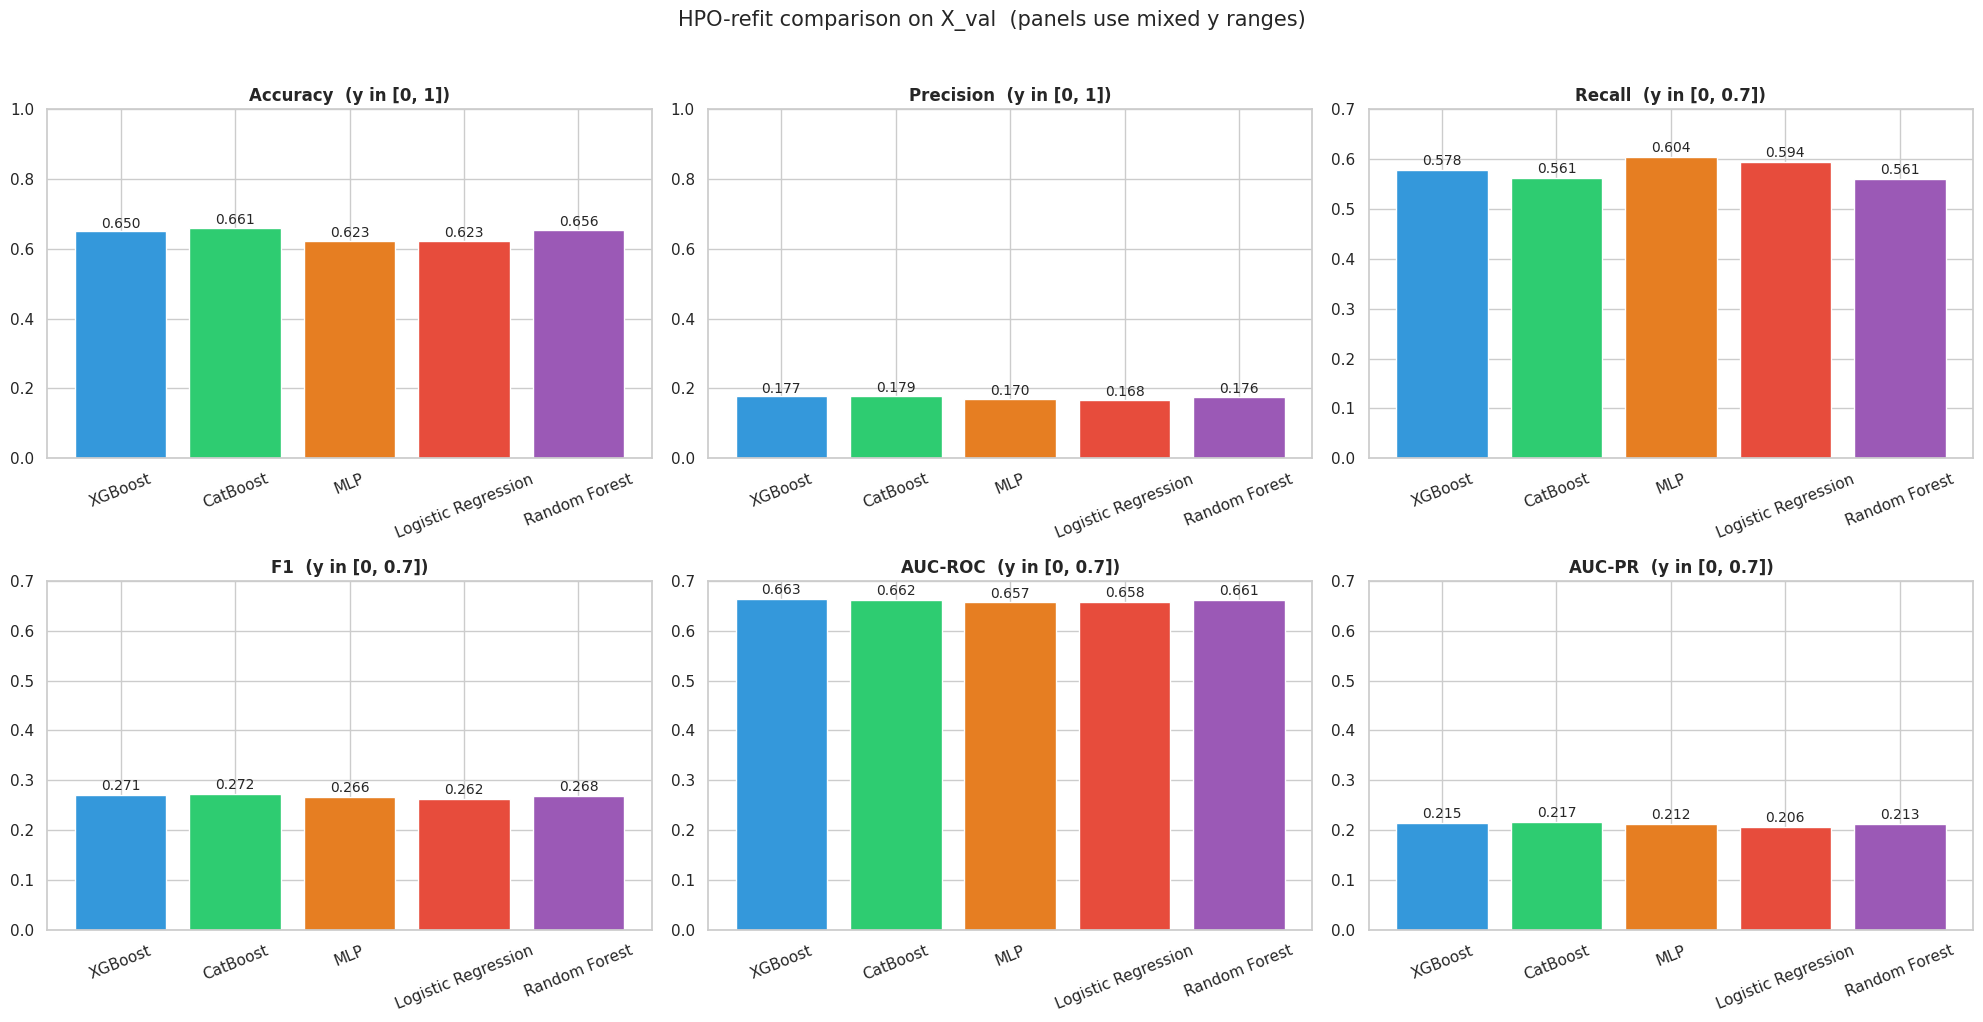

In [4]:
metric_keys = ["accuracy", "precision", "recall", "f1", "auc_roc", "auc_pr"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "AUC-PR"]
colors = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c", "#9b59b6"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
PANEL_YLIM = {"accuracy": (0, 1), "precision": (0, 1)}
DEFAULT_YLIM = (0, 0.7)
for ax, key, label in zip(axes.flat, metric_keys, metric_labels):
    vals = [results[m][key] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors[:len(model_names)], edgecolor="white")
    ylo, yhi = PANEL_YLIM.get(key, DEFAULT_YLIM)
    ax.set_title(f"{label}  (y in [{ylo}, {yhi}])", fontsize=12, fontweight="bold")
    ax.set_ylim(ylo, yhi)
    ax.tick_params(axis="x", rotation=22)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}",
                ha="center", fontsize=10)
plt.suptitle("HPO-refit comparison on X_val  (panels use mixed y ranges)", y=1.02, fontsize=15)
plt.tight_layout(); plt.show()

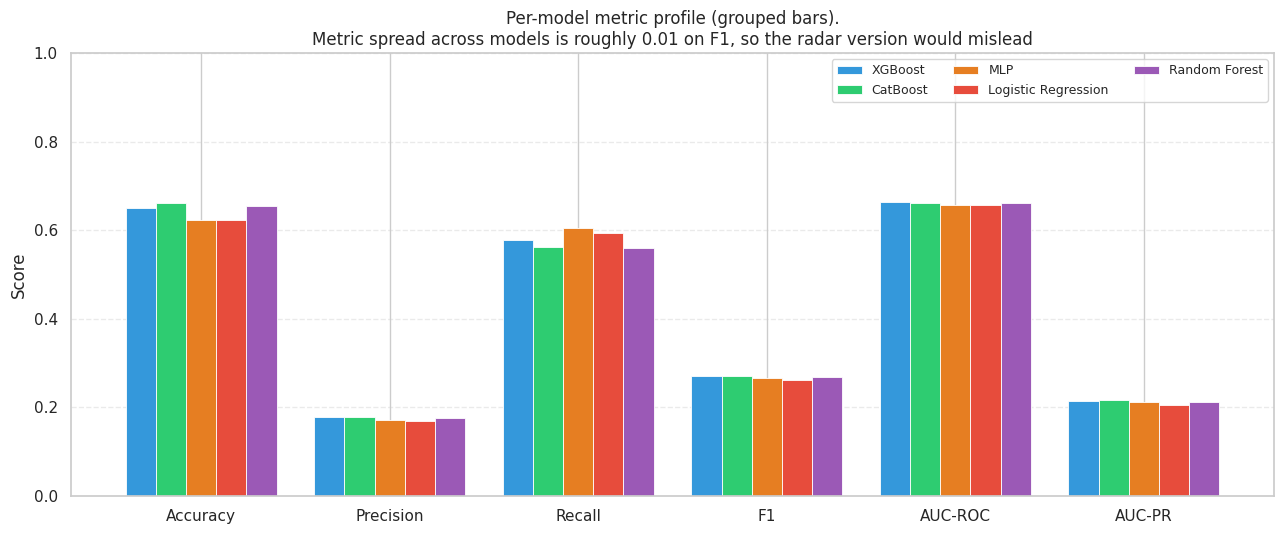

In [5]:
n = len(model_names)
x = np.arange(len(metric_keys))
bar_w = 0.8 / max(n, 1)

fig, ax = plt.subplots(figsize=(13, 5.5))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results[name][k] for k in metric_keys]
    offset = (i - (n - 1) / 2) * bar_w
    ax.bar(x + offset, vals, width=bar_w, color=color, edgecolor="white",
           linewidth=0.6, label=name)
ax.set_xticks(x); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title("Per-model metric profile (grouped bars).\n"
             "Metric spread across models is roughly 0.01 on F1, so the radar version would mislead")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper right", fontsize=9, ncol=min(n, 3))
plt.tight_layout(); plt.show()

In [6]:
metrics_df = pd.DataFrame({m: {k: results[m][k] for k in metric_keys}
                            for m in model_names}).T
metrics_df.columns = metric_labels
metrics_df = metrics_df.round(4)
print("HPO-refit summary on X_val:")
print(metrics_df.to_string())
print(f"\nBest F1:      {metrics_df['F1'].idxmax()} ({metrics_df['F1'].max():.4f})")
print(f"Best AUC-ROC: {metrics_df['AUC-ROC'].idxmax()} ({metrics_df['AUC-ROC'].max():.4f})")

HPO-refit summary on X_val:
                     Accuracy  Precision  Recall      F1  AUC-ROC  AUC-PR
XGBoost                0.6500     0.1771  0.5775  0.2711   0.6626  0.2148
CatBoost               0.6606     0.1791  0.5615  0.2716   0.6623  0.2166
MLP                    0.6233     0.1702  0.6043  0.2656   0.6565  0.2118
Logistic Regression    0.6232     0.1681  0.5936  0.2620   0.6577  0.2056
Random Forest          0.6555     0.1764  0.5606  0.2684   0.6613  0.2128

Best F1:      CatBoost (0.2716)
Best AUC-ROC: XGBoost (0.6626)


**Reading the comparison.** The F1 leader and the AUC-ROC leader may or may not be the same model. When they coincide, the choice is unambiguous. When they diverge, the F1 leader is preferred for notebook 8's selection rule, and the AUC-ROC leader is recorded as a fallback candidate in case the F1 leader fails the §7.5 overfit gate or the threshold-sensitivity test.

## 7.5 Overfit Check, Train vs Validation

**What we are computing.** Per-model training F1 and AUC-ROC alongside validation F1 and AUC-ROC, with the train-versus-validation gap printed for each metric. A gap above the 0.15 threshold from `helpers.constants.OVERFIT_THRESHOLD` signals that the model has memorised training-set patterns rather than learning generalisable structure.

**Why 0.15 here rather than 0.10 in notebook 6.** Notebook 6's fold-level gap threshold (0.10) is tighter because each CV fold is one third of training and noisier than the full 70/10 train-val split. This notebook's gap is computed on the full splits, so the looser 0.15 threshold is the right calibration.

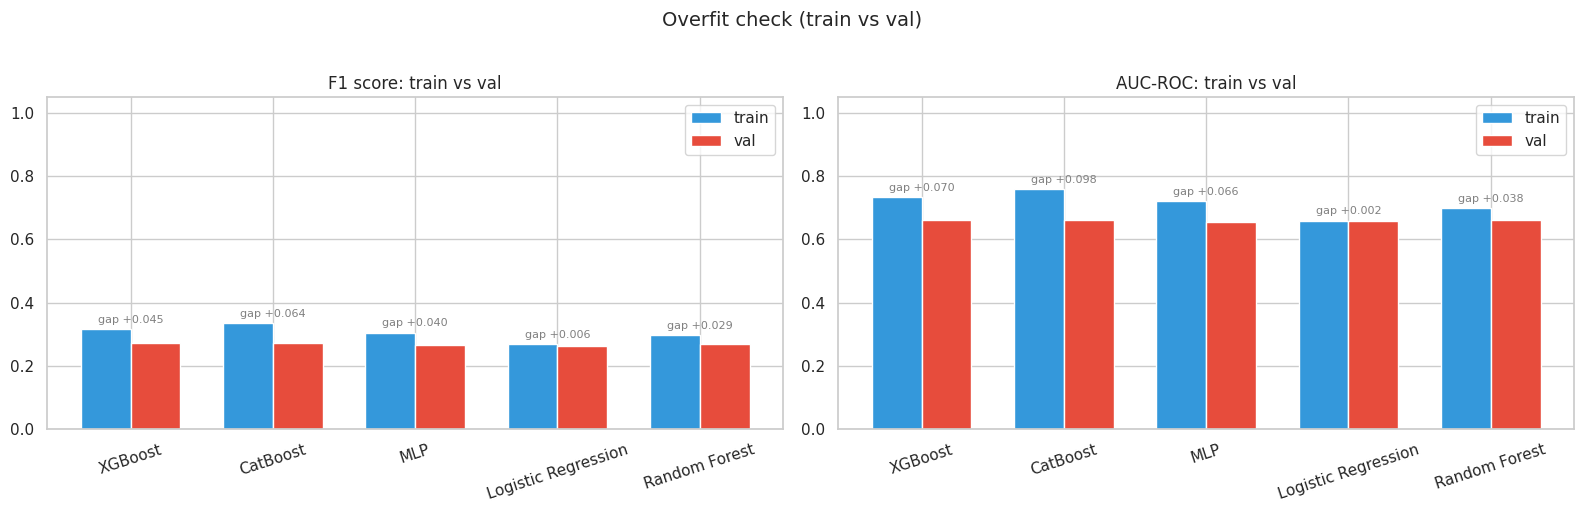

Overfit report (gate = 0.15):
  XGBoost                 F1 gap +0.0450  AUC gap +0.0704
  CatBoost                F1 gap +0.0642  AUC gap +0.0981
  MLP                     F1 gap +0.0398  AUC gap +0.0658
  Logistic Regression     F1 gap +0.0064  AUC gap +0.0019
  Random Forest           F1 gap +0.0287  AUC gap +0.0378


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x_pos = np.arange(len(model_names)); width = 0.35

for ax, train_key, val_key, title in [
    (axes[0], "train_f1", "f1", "F1 score"),
    (axes[1], "train_auc_roc", "auc_roc", "AUC-ROC"),
]:
    tr_vals = [results[m][train_key] for m in model_names]
    va_vals = [results[m][val_key] for m in model_names]
    ax.bar(x_pos - width/2, tr_vals, width, label="train", color="#3498db", edgecolor="white")
    ax.bar(x_pos + width/2, va_vals, width, label="val", color="#e74c3c", edgecolor="white")
    ax.set_xticks(x_pos); ax.set_xticklabels(model_names, rotation=18)
    ax.set_title(f"{title}: train vs val")
    ax.set_ylim(0, 1.05); ax.legend()
    for i in range(len(model_names)):
        gap = tr_vals[i] - va_vals[i]
        ax.annotate(f"gap {gap:+.3f}",
                    xy=(i, max(tr_vals[i], va_vals[i]) + 0.02),
                    ha="center", fontsize=8,
                    color="red" if gap > OVERFIT_THRESHOLD else "gray",
                    fontweight="bold" if gap > OVERFIT_THRESHOLD else "normal")

plt.suptitle("Overfit check (train vs val)", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

print(f"Overfit report (gate = {OVERFIT_THRESHOLD}):")
for name in model_names:
    f1_gap = results[name]["train_f1"] - results[name]["f1"]
    auc_gap = results[name]["train_auc_roc"] - results[name]["auc_roc"]
    flag = " !! OVERFIT" if max(f1_gap, auc_gap) > OVERFIT_THRESHOLD else ""
    print(f"  {name:22s}  F1 gap {f1_gap:+.4f}  AUC gap {auc_gap:+.4f}{flag}")

**Reading the gauge.** A flag here is a tuning prompt, not a hard fail signal. Class-weighted fits legitimately produce small positive gaps because the loss reweighting drives the model to memorise the minority class on training, while validation is computed without the reweighting. The §7.9 threshold sweep provides a second-line defence: even when the gap fires, threshold tuning recovers some validation F1 without retraining.

## 7.6 Confusion Matrices at the Default 0.5 Threshold

**What we are visualising.** One row-normalised confusion matrix per fitted model at the default 0.5 cutoff. Row-normalisation puts the colour scale on the per-class recall, so a glance at the diagonal reads off "fraction of true positives caught" and "fraction of true negatives correctly rejected" without arithmetic.

**Why the off-diagonal cells matter most.** For imbalanced data the on-diagonal cells are dominated by the easy majority-class predictions. The information lives in the off-diagonal cells: false negatives (missed readmissions, the clinically costly error) and false positives (false alarms, the operationally costly error).

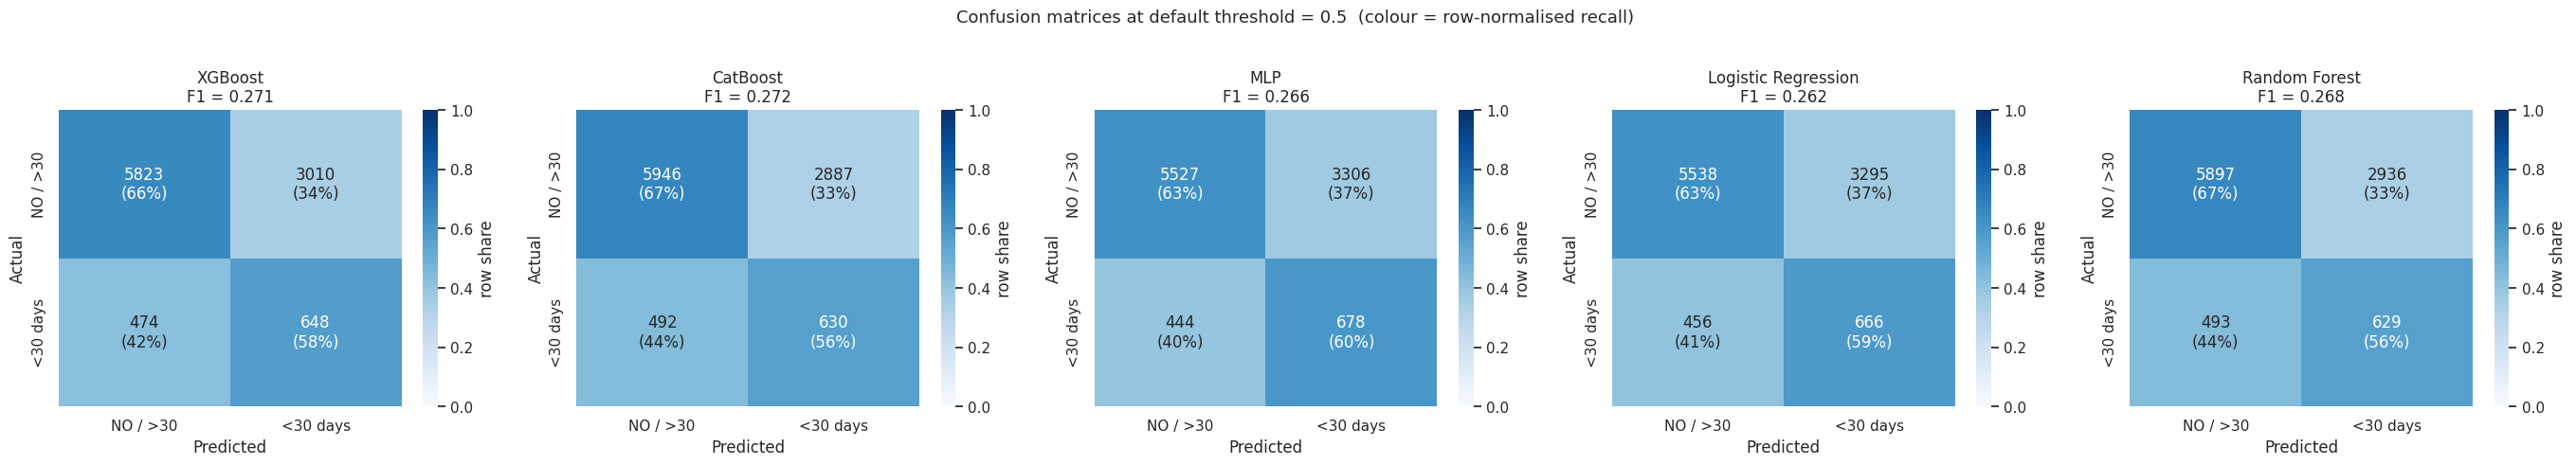

In [8]:
fig, axes = plt.subplots(1, len(model_names), figsize=(5.5 * len(model_names), 4.8))
if len(model_names) == 1:
    axes = [axes]
class_labels = ["NO / >30", "<30 days"]

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_val, results[name]["y_pred"])
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_norm[i, j]:.0%})"
    sns.heatmap(cm_norm, annot=annot, fmt="", cmap="Blues",
                vmin=0.0, vmax=1.0, ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={"label": "row share"})
    ax.set_title(f"{name}\nF1 = {results[name]['f1']:.3f}")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

plt.suptitle("Confusion matrices at default threshold = 0.5  (colour = row-normalised recall)",
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

**Reading the matrices.** A model with high false-negative count at the default threshold has a score distribution clustered low on the positive class (class-weight under-shoot). A model with high false-positive count has the opposite problem (overshoot). The §7.9 threshold sweep is designed to recover both modes by sliding the operating point off 0.5.

## 7.7 ROC and Precision-Recall Curves

**What we are visualising.** Both threshold-independent ranking diagnostics on `X_val`. The §7.4 dashboard and the §7.6 matrices fix a single operating point. ROC and PR sweep every threshold and trace the resulting trade-off.

**Why both curves.** They stress different things on imbalanced data. ROC stays comparable across thresholds and the AUC integrates a single ranking-quality number. PR has the prevalence baseline as its floor rather than 0.5, so its lift over prevalence is the cleaner multiplier for "how much better than random ranking is this model on the positive class".

**Why AUC-PR is not given equal weight as a primary selection metric.** AUC-PR rarely moves much across tuned configurations on this cohort because the model family determines the underlying ranking more than tuning does. F1 and AUC-ROC capture the threshold-positioning and ranking-quality stories respectively, which is what tuning is most likely to affect.

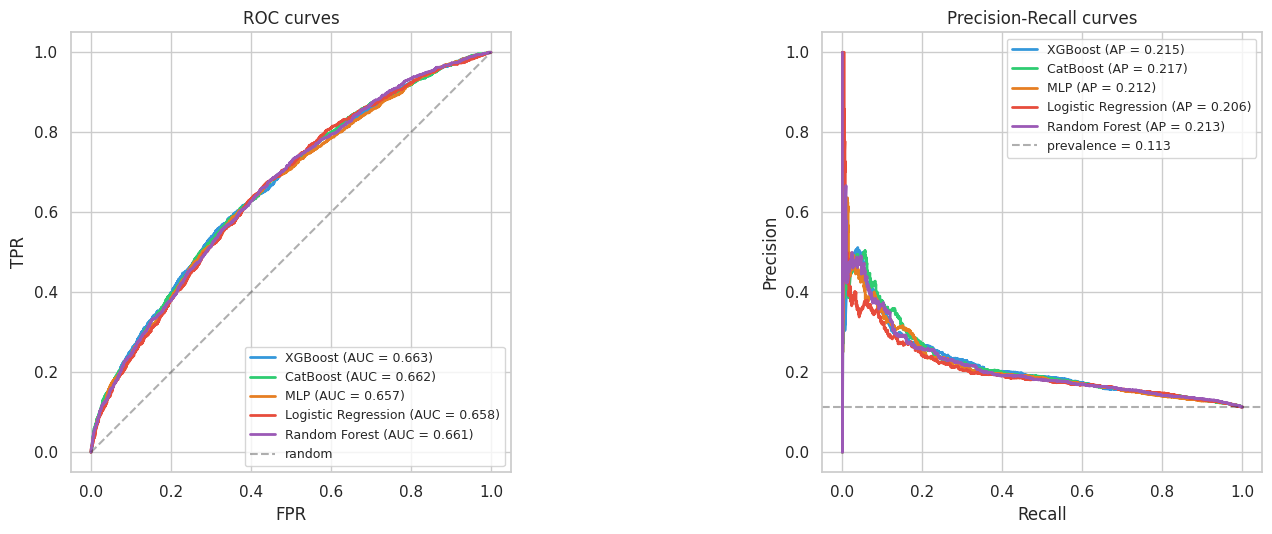

Prevalence floor on val: 0.113  (no-skill PR baseline)

Model                       AUC-ROC    AUC-PR   PR lift
  CatBoost                    0.662     0.217      1.92x
  XGBoost                     0.663     0.215      1.91x
  Random Forest               0.661     0.213      1.89x
  MLP                         0.657     0.212      1.88x
  Logistic Regression         0.658     0.206      1.82x


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, res["y_prob"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {res['auc_roc']:.3f})", color=color, linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.35, label="random")
axes[0].set_title("ROC curves"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(fontsize=9); axes[0].set_box_aspect(1)

for (name, res), color in zip(results.items(), colors):
    p, r, _ = precision_recall_curve(y_val, res["y_prob"])
    axes[1].plot(r, p, label=f"{name} (AP = {res['auc_pr']:.3f})", color=color, linewidth=2)
axes[1].axhline(y_val.mean(), color="k", ls="--", alpha=0.35,
                label=f"prevalence = {y_val.mean():.3f}")
axes[1].set_title("Precision-Recall curves"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=9); axes[1].set_box_aspect(1)

plt.tight_layout(); plt.show()

prev = float(y_val.mean())
print(f"Prevalence floor on val: {prev:.3f}  (no-skill PR baseline)\n")
print(f"{'Model':25s} {'AUC-ROC':>9s} {'AUC-PR':>9s} {'PR lift':>9s}")
for name, res in sorted(results.items(), key=lambda kv: -kv[1]['auc_pr']):
    lift = res['auc_pr'] / max(prev, 1e-6)
    print(f"  {name:23s} {res['auc_roc']:>9.3f} {res['auc_pr']:>9.3f} {lift:>9.2f}x")

**Reading the curves.** All families should sit visibly above the ROC diagonal at every operating point. Anything that hugs the diagonal is not better than chance. The PR floor at prevalence (roughly 0.11) is the more meaningful no-skill anchor here. A model with AP at two times prevalence has meaningful ranking power on the minority class. A model with AP near prevalence has no actionable signal regardless of how its AUC-ROC reads.

## 7.8 Calibration and Reliability

**Why calibration matters here.** The threshold sweep in §7.9 picks a cut on `predict_proba` values. If the model's probabilities are miscalibrated (the model claims 80 percent confidence but is only right 60 percent of the time), the chosen threshold is a number with no transferable meaning on new data. The reliability diagram bins predicted probability into ten deciles and plots the empirical positive rate within each bin. A perfectly calibrated model lies on the y=x diagonal. Tree ensembles routinely produce S-shaped curves (over-confident at the extremes). Logistic regression tends to be well-calibrated by construction.

**Why the score-distribution panel sits next to the reliability diagram.** A model whose probabilities concentrate near zero has no high-end deciles to calibrate. The histogram makes that constraint visible.

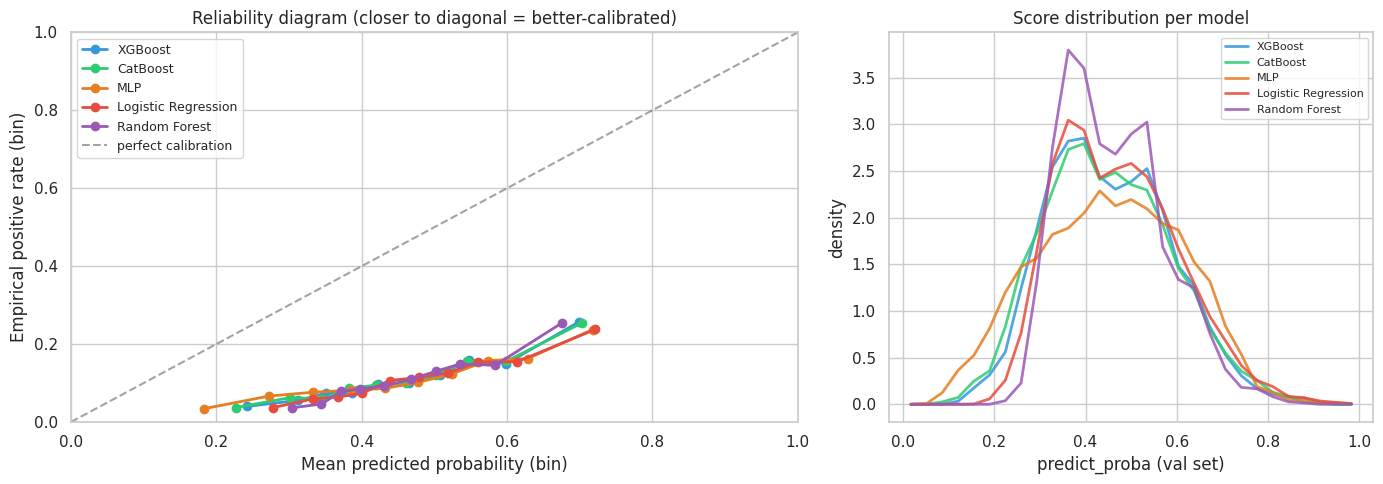

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          gridspec_kw={"width_ratios": [3, 2]})

for (name, res), color in zip(results.items(), colors):
    frac_pos, mean_pred = calibration_curve(y_val, res["y_prob"], n_bins=10, strategy="quantile")
    axes[0].plot(mean_pred, frac_pos, "o-", color=color, linewidth=2, markersize=6, label=name)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfect calibration")
axes[0].set_xlabel("Mean predicted probability (bin)")
axes[0].set_ylabel("Empirical positive rate (bin)")
axes[0].set_title("Reliability diagram (closer to diagonal = better-calibrated)")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9, loc="upper left")

bins = np.linspace(0, 1, 30); centers = (bins[:-1] + bins[1:]) / 2
for (name, res), color in zip(results.items(), colors):
    h, _ = np.histogram(res["y_prob"], bins=bins, density=True)
    axes[1].plot(centers, h, color=color, linewidth=2, label=name, alpha=0.85)
axes[1].set_xlabel("predict_proba (val set)")
axes[1].set_ylabel("density")
axes[1].set_title("Score distribution per model")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the calibration panels.** Logistic regression typically lands closest to the diagonal because its loss function is proper-scoring by construction. Tree ensembles often show an S-shape, with confident-zero and confident-one predictions slightly miscalibrated and the middle deciles closer to the diagonal. The score-distribution panel explains where each model has resolution to calibrate against. A model whose mass concentrates in the lowest decile has nothing to calibrate at the high end and gets paired with isotonic regression in §6.12 step 1 if calibration is needed at deploy time.

## 7.9 Decision-Threshold Optimisation

**What we are doing.** Sweeping decision thresholds on `X_val` for each model and picking the F1-maximising cut.

**Why the default 0.5 threshold is wrong by default for imbalanced data.** A class-weighted model's score distribution on the positive class sits low. The 0.5 cut applied to that distribution misses most positives. The F1-optimal threshold typically sits well below 0.5, and finding it is a no-cost recovery that requires no retraining.

**Why threshold tuning happens on `X_val` rather than via cross-validation.** `X_val` is disjoint from `X_train` at the patient level by construction. The threshold chosen on `X_val` and applied back to `X_val` is slightly optimistic because the same set drove both the choice and the evaluation. Notebook 8 §8.8 re-derives the same sweep on `X_test` to confirm whether the operating point transfers honestly.

**Why F1 rather than F2.** F1 weights precision and recall equally. F2 weights recall four times as heavily as precision and is the right choice when the cost asymmetry between false negatives and false positives is known to favour recall. The CMS Hospital Readmissions Reduction Program does not levy a per-readmission dollar fine. It adjusts a hospital's base operating DRG payments downward by an excess-readmission-ratio-derived factor capped at 3 percent of those payments per fiscal year (CMS HRRP, https://www.cms.gov/medicare/payment/prospective-payment-systems/acute-inpatient-pps/hospital-readmissions-reduction-program-hrrp). Published health-economics estimates put the implied per-missed-readmission HRRP exposure in the low-thousand-USD range and care-coordination interventions in the low-hundred-USD range, placing the cost ratio in the roughly 5x to 10x band and making F2 the directionally correct choice once the operations team supplies per-event costs for this hospital's payment base and patient mix. At a 3x ratio F1 remains optimal, so this notebook commits F1 as the holding decision rather than baking a particular dollar ratio into the threshold rule.

Threshold optimisation (tuned and evaluated on X_val):
Model                        t*   F1@0.5    F1@t*     gain   Recall@t*
---------------------------------------------------------------------------
  XGBoost                0.5188   0.2711   0.2765  +0.0054      0.5339
  CatBoost               0.5243   0.2716   0.2750  +0.0034      0.5027
  MLP                    0.5463   0.2656   0.2717  +0.0062      0.5027
  Logistic Regression    0.5358   0.2620   0.2678  +0.0058      0.4973
  Random Forest          0.5025   0.2684   0.2697  +0.0013      0.5553


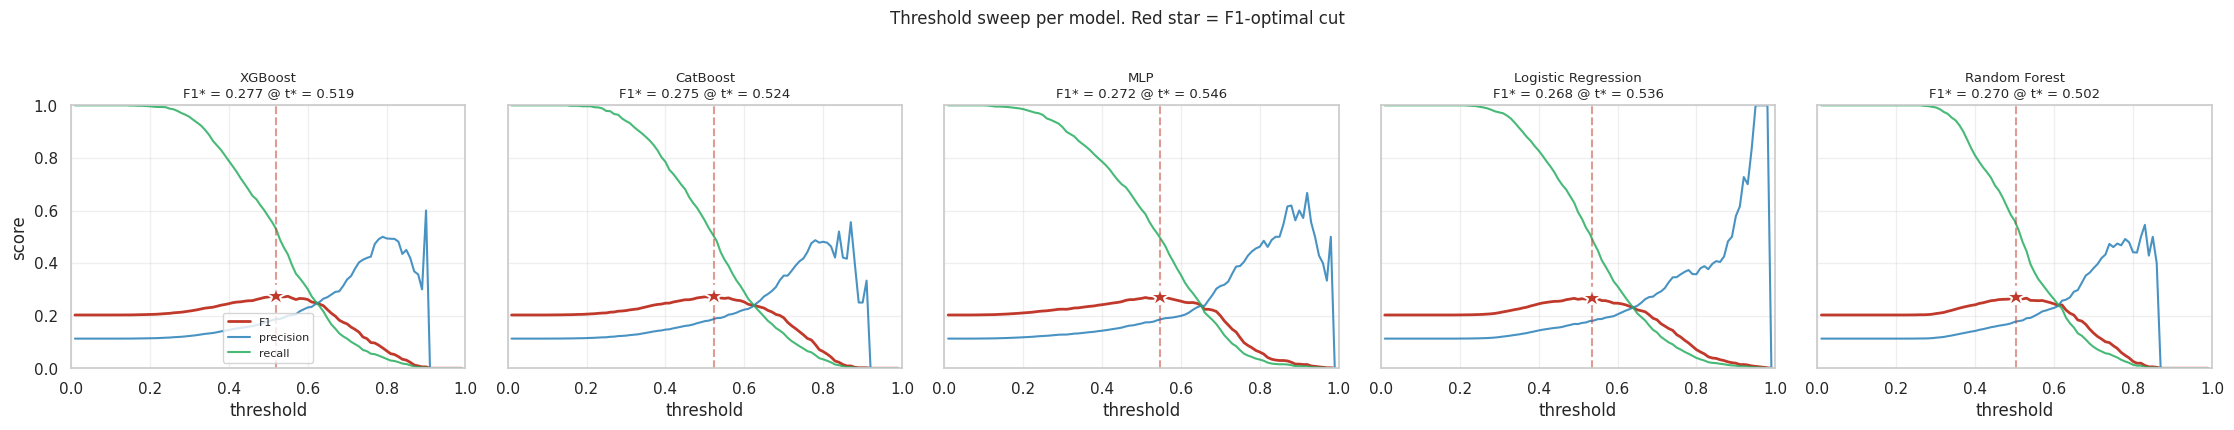

In [11]:
print("Threshold optimisation (tuned and evaluated on X_val):")
print(f"{'Model':22s} {'t*':>8s} {'F1@0.5':>8s} {'F1@t*':>8s} {'gain':>8s} {'Recall@t*':>11s}")
print("-" * 75)
for name, tr in threshold_results.items():
    gain = tr["f1_optimized"] - tr["f1_default"]
    print(f"  {name:20s} {tr['optimal_threshold']:>8.4f} "
          f"{tr['f1_default']:>8.4f} {tr['f1_optimized']:>8.4f} "
          f"{gain:>+8.4f} {tr['recall_optimized']:>11.4f}")

fig, axes = plt.subplots(1, len(model_names), figsize=(4.5 * len(model_names), 4.2), sharey=True)
if len(model_names) == 1:
    axes = [axes]
grid = np.linspace(0.01, 0.99, 99)
for ax, name in zip(axes, model_names):
    y_prob = results[name]["y_prob"]
    f1s = []; ps = []; rs = []
    for t in grid:
        yhat = (y_prob >= t).astype(int)
        p, r, f, _ = precision_recall_fscore_support(y_val, yhat, average="binary", zero_division=0)
        f1s.append(f); ps.append(p); rs.append(r)
    ax.plot(grid, f1s, color="#c0392b", lw=2, label="F1")
    ax.plot(grid, ps, color="#2980b9", lw=1.5, label="precision", alpha=0.85)
    ax.plot(grid, rs, color="#27ae60", lw=1.5, label="recall", alpha=0.85)
    t_star = threshold_results[name]["optimal_threshold"]
    f1_star = threshold_results[name]["f1_optimized"]
    ax.axvline(t_star, color="#c0392b", linestyle="--", alpha=0.5)
    ax.plot([t_star], [f1_star], marker="*", color="#c0392b",
            markersize=16, markeredgecolor="white", markeredgewidth=1.5, zorder=5)
    ax.set_title(f"{name}\nF1* = {f1_star:.3f} @ t* = {t_star:.3f}", fontsize=9.5)
    ax.set_xlabel("threshold"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel("score"); ax.legend(loc="lower center", fontsize=8)

plt.suptitle("Threshold sweep per model. Red star = F1-optimal cut",
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

**Reading the sweep.** A flat curve around the F1-optimal cut means the choice is robust to small score-distribution shifts at deploy time. A peaked curve means the choice is fragile. The gain column tells the operations team the size of the recall recovery that threshold tuning alone delivers on each candidate.

## 7.10 Confusion Matrices at Optimised Thresholds

**What we are visualising.** The §7.6 confusion-matrix view rendered at each model's tuned threshold instead of 0.5, with the per-model F1 and chosen threshold annotated.

**What changes between the two matrix sets.** True positives grow (because the lowered threshold flags more borderline patients as `<30 days`, and the truly positive ones move from FN into TP), false negatives shrink correspondingly, false positives typically grow (more flags means more false alarms), and true negatives shrink slightly. The size of the FN reduction quantifies the operational lift threshold tuning buys.

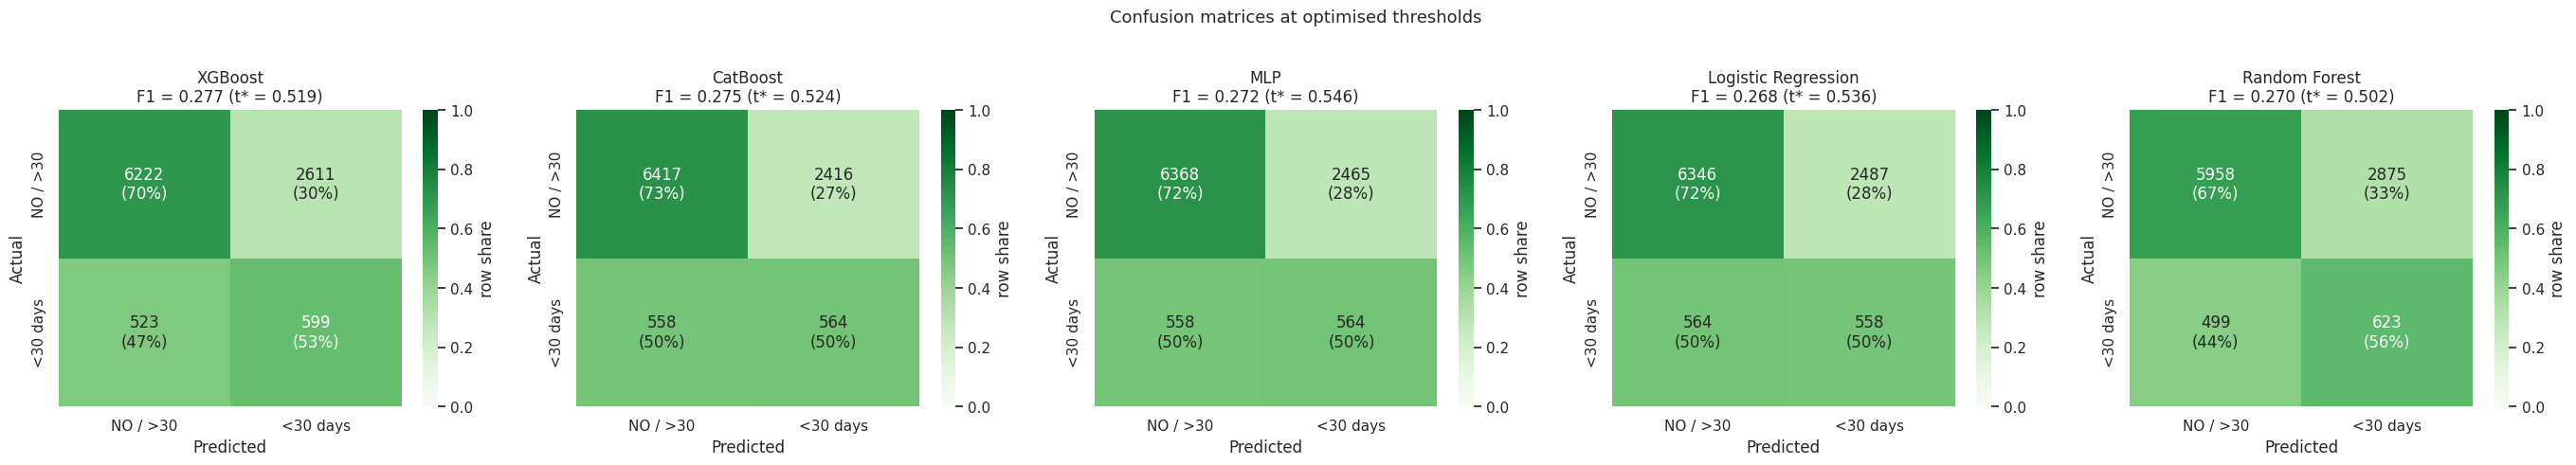

Default-vs-optimised comparison:
  XGBoost                 threshold 0.5 -> 0.519
    F1:     0.2711 -> 0.2765
    Recall: 0.5775 -> 0.5339
  CatBoost                threshold 0.5 -> 0.524
    F1:     0.2716 -> 0.2750
    Recall: 0.5615 -> 0.5027
  MLP                     threshold 0.5 -> 0.546
    F1:     0.2656 -> 0.2717
    Recall: 0.6043 -> 0.5027
  Logistic Regression     threshold 0.5 -> 0.536
    F1:     0.2620 -> 0.2678
    Recall: 0.5936 -> 0.4973
  Random Forest           threshold 0.5 -> 0.502
    F1:     0.2684 -> 0.2697
    Recall: 0.5606 -> 0.5553


In [12]:
fig, axes = plt.subplots(1, len(model_names), figsize=(5.5 * len(model_names), 4.8))
if len(model_names) == 1:
    axes = [axes]

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_val, results[name]["y_pred_opt"])
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_norm[i, j]:.0%})"
    sns.heatmap(cm_norm, annot=annot, fmt="", cmap="Greens",
                vmin=0.0, vmax=1.0, ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={"label": "row share"})
    tr = threshold_results[name]
    ax.set_title(f"{name}\nF1 = {tr['f1_optimized']:.3f} (t* = {tr['optimal_threshold']:.3f})")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

plt.suptitle("Confusion matrices at optimised thresholds", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

print("Default-vs-optimised comparison:")
for name in model_names:
    tr = threshold_results[name]
    print(f"  {name:22s}  threshold 0.5 -> {tr['optimal_threshold']:.3f}")
    print(f"    F1:     {tr['f1_default']:.4f} -> {tr['f1_optimized']:.4f}")
    print(f"    Recall: {tr['recall_default']:.4f} -> {tr['recall_optimized']:.4f}")

**Reading the matrices against §7.6.** Threshold tuning does not change the model's underlying ranking quality. AUC-ROC and AUC-PR are unchanged. It only changes the operating point. If a model's minority-class recall is still low after tuning, the limit is the score quality, not the cut, and the model needs feature engineering or an architectural change rather than another threshold pass.

## 7.11 Per-Class Classification Reports

**What we are inspecting.** Per-class precision, recall, and F1 at the default 0.5 threshold (for direct comparison with §7.6) and at the optimised thresholds (for parity with §7.10).

**Why per-class.** The `<30 days` row is the row that matters for selection. Precision tells the operations team what fraction of flagged patients was truly readmitted within 30 days. Recall tells them what fraction of true 30-day readmissions was caught. The F1 in that row is the primary selection metric at the default cut. The `macro avg` row is a fairer single-number summary on imbalanced data than `accuracy`, and is reported here for completeness.

In [13]:
for name in model_names:
    print(f"{'=' * 60}")
    print(f"  {name}  (default threshold = 0.5)")
    print(f"{'=' * 60}")
    print(classification_report(y_val, results[name]["y_pred"],
                                target_names=["NO / >30 days", "<30 days"]))

  XGBoost  (default threshold = 0.5)
               precision    recall  f1-score   support

NO / >30 days       0.92      0.66      0.77      8833
     <30 days       0.18      0.58      0.27      1122

     accuracy                           0.65      9955
    macro avg       0.55      0.62      0.52      9955
 weighted avg       0.84      0.65      0.71      9955

  CatBoost  (default threshold = 0.5)
               precision    recall  f1-score   support

NO / >30 days       0.92      0.67      0.78      8833
     <30 days       0.18      0.56      0.27      1122

     accuracy                           0.66      9955
    macro avg       0.55      0.62      0.53      9955
 weighted avg       0.84      0.66      0.72      9955

  MLP  (default threshold = 0.5)
               precision    recall  f1-score   support

NO / >30 days       0.93      0.63      0.75      8833
     <30 days       0.17      0.60      0.27      1122

     accuracy                           0.62      9955
    

In [14]:
print("§7.11 verdict, sorted by <30-days F1 at default threshold:")
rows = []
for name in model_names:
    p, r, f, _ = precision_recall_fscore_support(
        y_val, results[name]["y_pred"], labels=[0, 1], zero_division=0)
    rows.append((name, float(p[1]), float(r[1]), float(f[1])))
rows.sort(key=lambda x: -x[3])

print(f"  {'Model':22s} {'precision':>10s} {'recall':>9s} {'F1':>9s}  flag")
for name, p, r, f in rows:
    flag = "BOUNDARY-TOO-CONSERVATIVE" if r < 0.05 else ""
    print(f"  {name:22s} {p:>10.3f} {r:>9.3f} {f:>9.3f}  {flag}")
print(f"\n<30-days F1 leader at default threshold: {rows[0][0]} (F1 = {rows[0][3]:.3f})")
print("Models flagged BOUNDARY-TOO-CONSERVATIVE need the §7.9 threshold sweep "
      "to lift recall above the 0.05 floor.")

§7.11 verdict, sorted by <30-days F1 at default threshold:
  Model                   precision    recall        F1  flag
  CatBoost                    0.179     0.561     0.272  
  XGBoost                     0.177     0.578     0.271  
  Random Forest               0.176     0.561     0.268  
  MLP                         0.170     0.604     0.266  
  Logistic Regression         0.168     0.594     0.262  

<30-days F1 leader at default threshold: CatBoost (F1 = 0.272)
Models flagged BOUNDARY-TOO-CONSERVATIVE need the §7.9 threshold sweep to lift recall above the 0.05 floor.


**Reading the verdict.** Any model whose minority-class recall sits below 0.05 at the default 0.5 cut despite class weighting is in the boundary-too-conservative failure mode. Class weighting alone did not push the decision boundary far enough into minority territory. The §7.9 threshold sweep is the standard rescue. Models flagged here are not eliminated outright. They re-enter the notebook 8 leaderboard after the sweep gives them a fair operating point.

## 7.12 Feature Importance, Tree-Based Models

**What we are inspecting.** Native `feature_importances_` rankings from each fitted tree model, normalised to sum to one so the per-model x-axes are directly comparable, with a cross-family rank-agreement heatmap that surfaces the features every tree model agrees on.

**Why normalise.** XGBoost's gain, scikit-learn's RandomForest mean-impurity-decrease, and CatBoost's PredictionValuesChange are on different absolute scales. Without normalisation the bar widths would look deceptively similar across panels. Normalising to a per-model share converts each panel into a "fraction of total importance" view that lets the reader compare concentrations honestly.

**Why the ranking matters more than the absolute number.** Absolute importance is scale-dependent and not comparable across model families. The ranking is. If three different tree models all surface `number_inpatient` and `num_medications` as their top features, the signal is real. If each tree surfaces a different top feature, the predictive signal is diffuse and the model is finding marginal patterns rather than dominant ones.

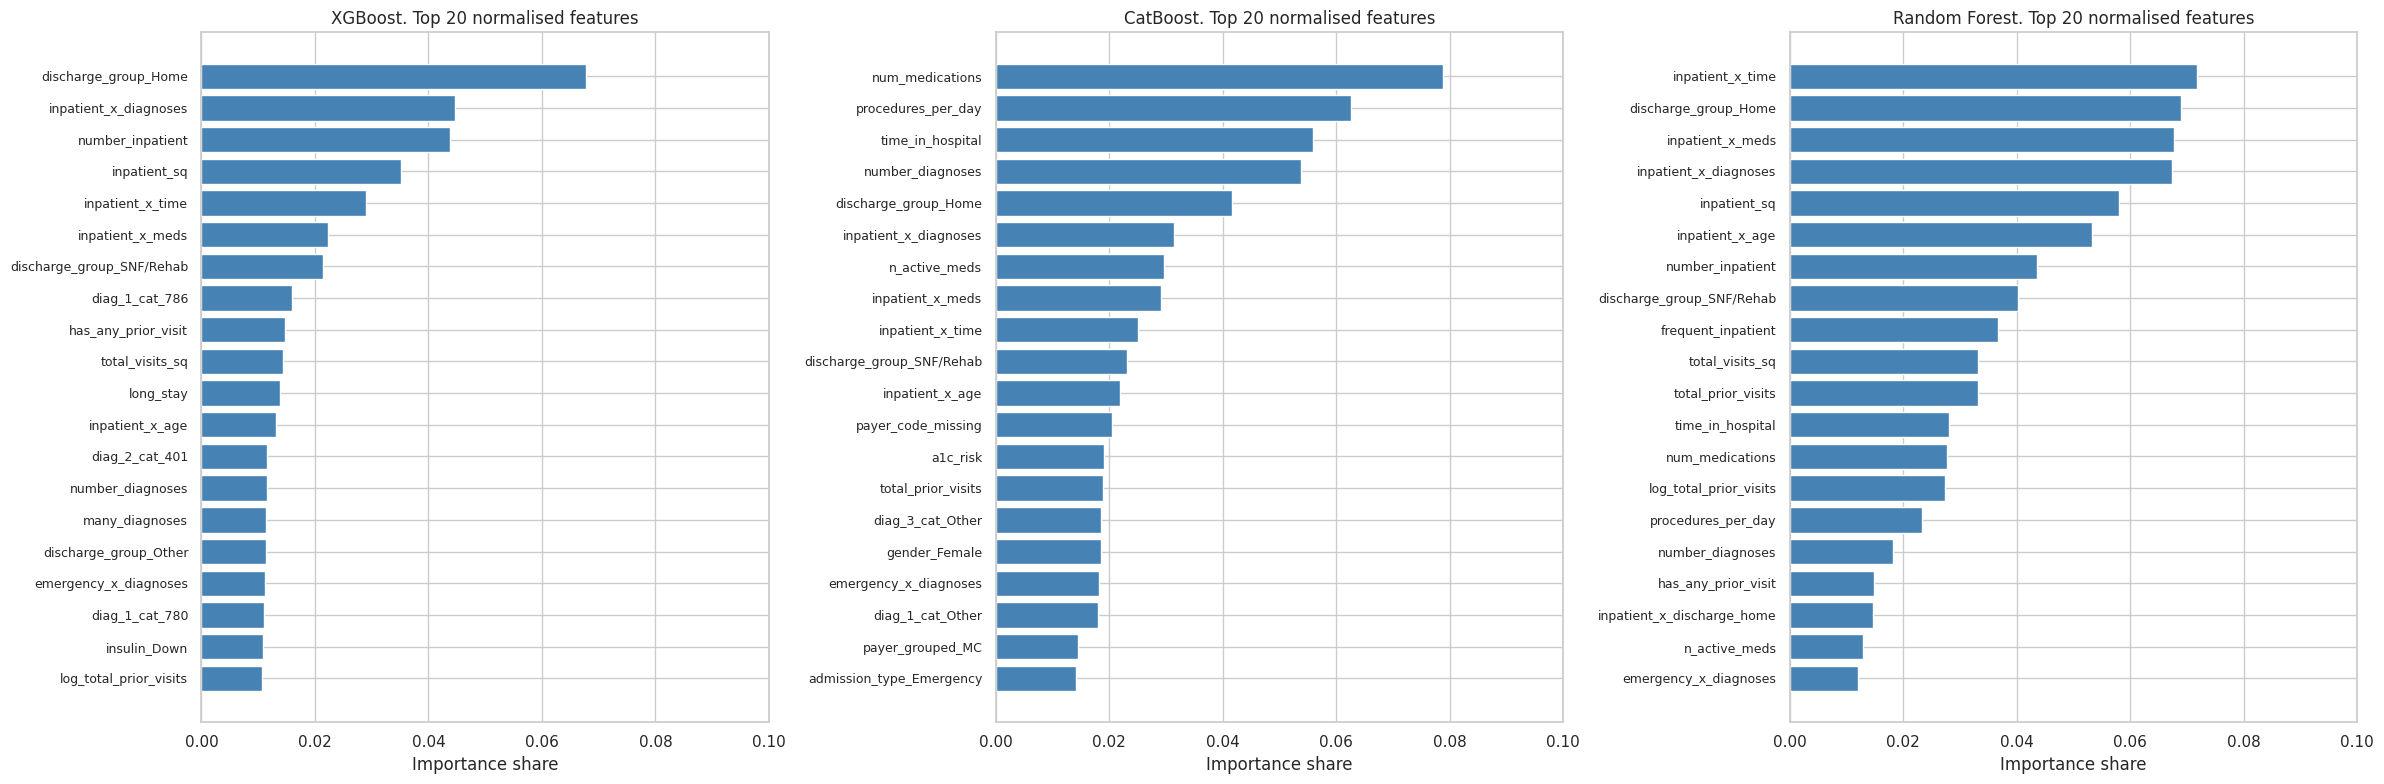

In [15]:
tree_models = {k: m for k, m in fitted_models.items()
                if hasattr(m, "feature_importances_")}

if not tree_models:
    print("No tree-based models present. Skipping feature-importance section.")
else:
    fig, axes = plt.subplots(1, len(tree_models), figsize=(8 * len(tree_models), 8))
    if len(tree_models) == 1:
        axes = [axes]
    top_n = 20
    for ax, (name, m) in zip(axes, tree_models.items()):
        importances = m.feature_importances_
        if hasattr(importances, "get"):
            importances = importances.get()
        total = float(importances.sum())
        if total > 0:
            importances = importances / total
        idx = np.argsort(importances)[-top_n:]
        feats = [feature_names[i] for i in idx]
        vals = importances[idx]
        ax.barh(range(top_n), vals, color="steelblue", edgecolor="white")
        ax.set_yticks(range(top_n)); ax.set_yticklabels(feats, fontsize=9)
        ax.set_title(f"{name}. Top {top_n} normalised features")
        ax.set_xlabel("Importance share")
        ax.set_xlim(0, max(0.10, vals.max() * 1.1))
    plt.tight_layout(); plt.show()

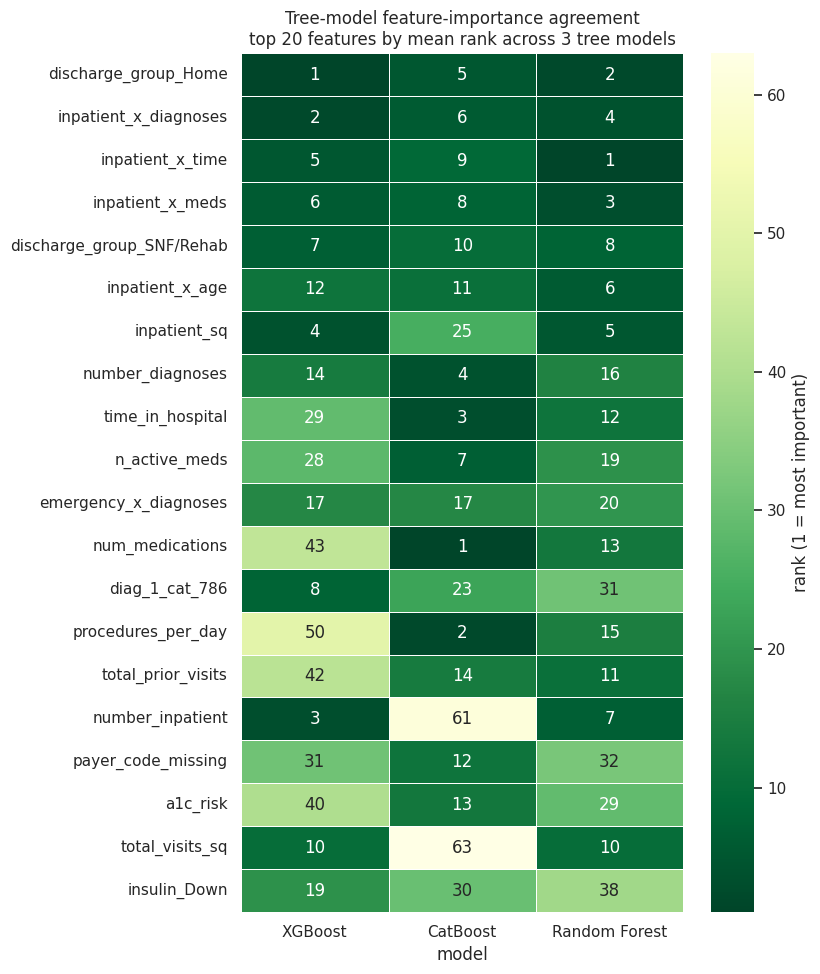

In [16]:
if len(tree_models) >= 2:
    rank_per_model = {}
    for name, m in tree_models.items():
        imp = m.feature_importances_
        if hasattr(imp, "get"):
            imp = imp.get()
        order = np.argsort(-imp)
        ranks = np.empty_like(order)
        ranks[order] = np.arange(1, len(order) + 1)
        rank_per_model[name] = ranks
    ranks_df = pd.DataFrame(rank_per_model, index=feature_names)
    ranks_df["__mean_rank__"] = ranks_df.mean(axis=1)
    top = (ranks_df.sort_values("__mean_rank__").head(20)
                   .drop(columns=["__mean_rank__"]))
    fig, ax = plt.subplots(figsize=(1.4 * len(top.columns) + 4, 0.42 * len(top) + 1.5))
    max_rank = float(top.values.max())
    sns.heatmap(top, annot=True, fmt="d", cmap="YlGn_r", vmin=1, vmax=max_rank,
                cbar_kws={"label": "rank (1 = most important)"}, ax=ax,
                linewidths=0.5, linecolor="white")
    ax.set_title(f"Tree-model feature-importance agreement\n"
                 f"top 20 features by mean rank across {len(tree_models)} tree models")
    ax.set_xlabel("model"); ax.set_ylabel("")
    plt.tight_layout(); plt.show()
else:
    print(f"Skipping agreement chart, only {len(tree_models)} tree model(s) available.")

**Reading the rank-agreement heatmap.** Features that every tree model puts in its top set either share signal (the safe interpretation) or share an artefact of the heuristic the trees use to rank importance (the suspicious interpretation). `sklearn.inspection.permutation_importance` is the model-agnostic recheck that resolves the ambiguity. Importance scores across XGBoost, RandomForest, and CatBoost are not directly comparable because the three definitions measure different things, so the ranking is informative but the magnitudes are not.

**What to do if the top features are unexpected.** Cross-check against the notebook 3 §3.6.5 point-biserial correlations. A feature that ranks high here but had near-zero correlation with the target there is suspicious and warrants a leakage check. Re-fit the model with class-weighting disabled to see whether the top features change. Class weighting can inflate the importance of features that correlate with the minority class through artefactual patterns.

## 7.13 Persisted Artefacts and Summary

**What this stage wrote.**

* `data/training_models.joblib` and `data/training_results.joblib`: HPO-refit fitted estimators and their validation metrics.
* `data/default_models.joblib` and `data/default_results.joblib`: library-default fitted estimators and their validation metrics.
* `data/model_thresholds.joblib`: per-model F1-optimal decision thresholds from §7.9.
* `data/final_model.joblib` and `data/final_model_threshold.joblib`: the highest-validation-F1 estimator at the default 0.5 cut, saved as a starting champion bundle so the serving layer has something to load even if the notebook 8 conclusion stage is skipped.
* `data/mlp_results.joblib`: the HPO-selected MLP hyperparameter dict and epoch budget, read by `helpers.mlp_train.nb07_best_epoch` and `nb08_best_config` so the out-of-fold MLP loops align with the production MLP.

**Why this notebook does not register to MLflow's Model Registry.** Registration belongs in notebook 8 after the held-out test pass. Registering a candidate without a test-set lift confidence interval would put unvetted versions in front of the inference API and break the gate-champion contract the retrain DAG relies on.

In [17]:
for art in ("training_models.joblib", "training_results.joblib",
            "default_models.joblib", "default_results.joblib",
            "model_thresholds.joblib", "final_model.joblib",
            "final_model_threshold.joblib", "mlp_results.joblib"):
    p = PROJECT_ROOT / "data" / art
    if p.exists():
        print(f"  {art:36s}  {p.stat().st_size / 1024:>8.1f} KB")
    else:
        print(f"  {art:36s}  MISSING")

print("\nFinal model ranking by validation F1 at default 0.5:")
ranked = sorted(results.items(), key=lambda kv: -kv[1]['f1'])
for i, (name, res) in enumerate(ranked, 1):
    print(f"  {i}. {name}: F1 = {res['f1']:.4f}, AUC-ROC = {res['auc_roc']:.4f}, Recall = {res['recall']:.4f}")

  training_models.joblib                 10936.5 KB
  training_results.joblib                 1090.6 KB
  default_models.joblib                 200926.6 KB
  default_results.joblib                   701.3 KB
  model_thresholds.joblib                    0.1 KB
  final_model.joblib                       639.8 KB
  final_model_threshold.joblib               0.0 KB
  mlp_results.joblib                         0.1 KB

Final model ranking by validation F1 at default 0.5:
  1. CatBoost: F1 = 0.2716, AUC-ROC = 0.6623, Recall = 0.5615
  2. XGBoost: F1 = 0.2711, AUC-ROC = 0.6626, Recall = 0.5775
  3. Random Forest: F1 = 0.2684, AUC-ROC = 0.6613, Recall = 0.5606
  4. MLP: F1 = 0.2656, AUC-ROC = 0.6565, Recall = 0.6043
  5. Logistic Regression: F1 = 0.2620, AUC-ROC = 0.6577, Recall = 0.5936
